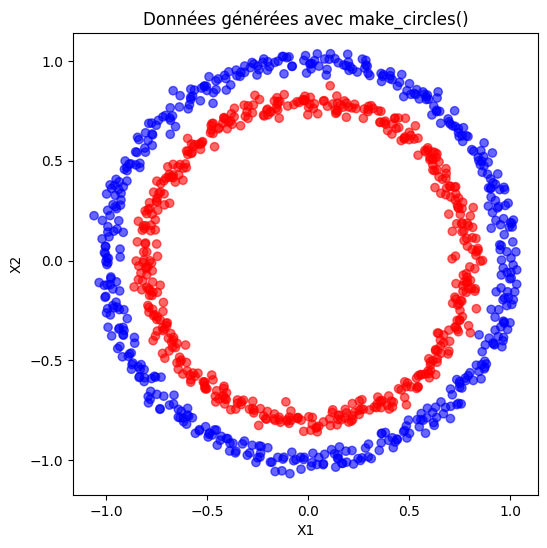

In [ ]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt


X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Données générées avec make_circles()")
plt.show()


In [ ]:
print(X.size)
print(y.size)

2000
1000


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Taille de l'ensemble d'entraînement :", X_train.shape, y_train.shape)
print("Taille de l'ensemble de test :", X_test.shape, y_test.shape)

Taille de l'ensemble d'entraînement : (800, 2) (800,)
Taille de l'ensemble de test : (200, 2) (200,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import SGD


model.compile(optimizer=SGD(), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=0)

for i in range(0, 100, 10):
    loss, acc = history.history['loss'][i], history.history['accuracy'][i]
    val_loss, val_acc = history.history['val_loss'][i], history.history['val_accuracy'][i]
    print(f"Époque {i+1}: Loss={loss:.4f}, Acc={acc:.4f}, Test Loss={val_loss:.4f}, Test Acc={val_acc:.4f}")


Époque 1: Loss=0.6930, Acc=0.4863, Test Loss=0.6913, Test Acc=0.5400
Époque 11: Loss=0.6905, Acc=0.5863, Test Loss=0.6907, Test Acc=0.5950
Époque 21: Loss=0.6879, Acc=0.6775, Test Loss=0.6895, Test Acc=0.6200
Époque 31: Loss=0.6840, Acc=0.6650, Test Loss=0.6869, Test Acc=0.5850
Époque 41: Loss=0.6790, Acc=0.7688, Test Loss=0.6828, Test Acc=0.6500
Époque 51: Loss=0.6733, Acc=0.8087, Test Loss=0.6782, Test Acc=0.7050
Époque 61: Loss=0.6661, Acc=0.8612, Test Loss=0.6721, Test Acc=0.7600
Époque 71: Loss=0.6563, Acc=0.8838, Test Loss=0.6636, Test Acc=0.7750
Époque 81: Loss=0.6428, Acc=0.8913, Test Loss=0.6514, Test Acc=0.8450
Époque 91: Loss=0.6204, Acc=0.9563, Test Loss=0.6313, Test Acc=0.9250


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


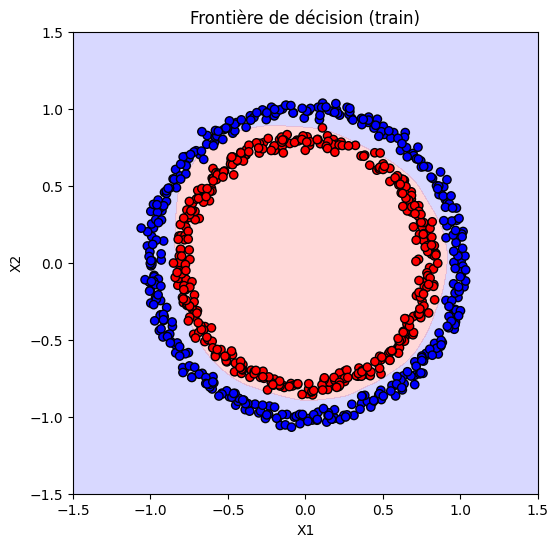

In [ ]:
import numpy as np
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, preds, levels=[0, 0.5, 1], alpha=0.3, cmap='bwr')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolors='k')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Frontière de décision (train)")
plt.show()

Train set: 800 échantillons
Test set: 200 échantillons


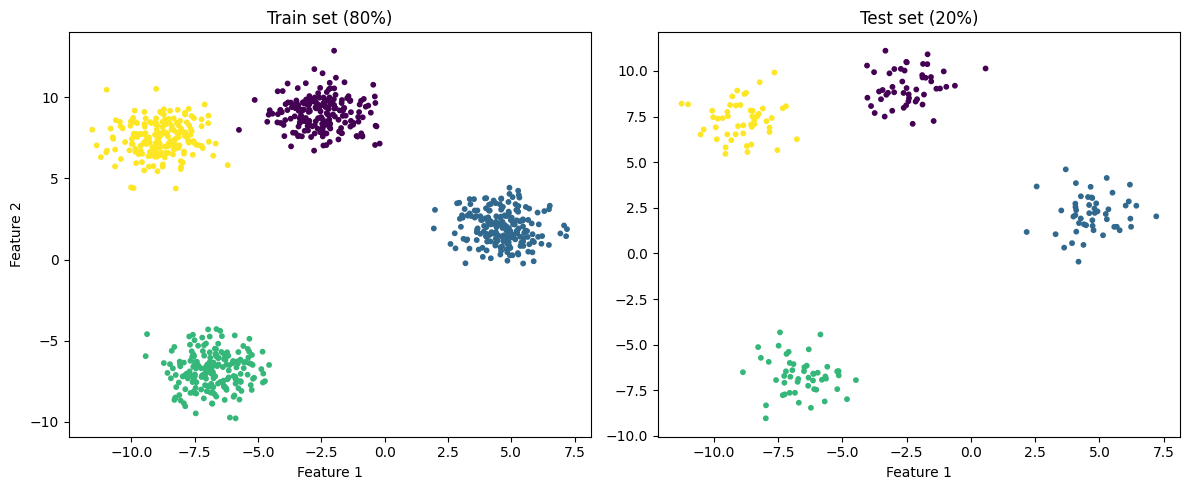

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=1000,  # 1000 échantillons
    n_features=2,    # 2 features
    centers=4,       # 4 classes
    random_state=42  # Reproductibilité
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42,    # Pour la reproductibilité
    stratify=y          # Conserve la répartition des classes
)

print(f"Train set: {X_train.shape[0]} échantillons")
print(f"Test set: {X_test.shape[0]} échantillons")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', s=10)
plt.title("Train set (80%)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', s=10)
plt.title("Test set (20%)")
plt.xlabel("Feature 1")

plt.tight_layout()
plt.show()

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6863 - loss: 1.0888 - val_accuracy: 0.9900 - val_loss: 0.3023
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9942 - loss: 0.2312 - val_accuracy: 1.0000 - val_loss: 0.0864
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0707 - val_accuracy: 1.0000 - val_loss: 0.0403
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9991 - loss: 0.0365 - val_accuracy: 1.0000 - val_loss: 0.0229
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9994 - loss: 0.0211 - val_accuracy: 1.0000 - val_loss: 0.0147
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9981 - loss: 0.0149 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9985 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 0.0078
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9985 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 1.0000


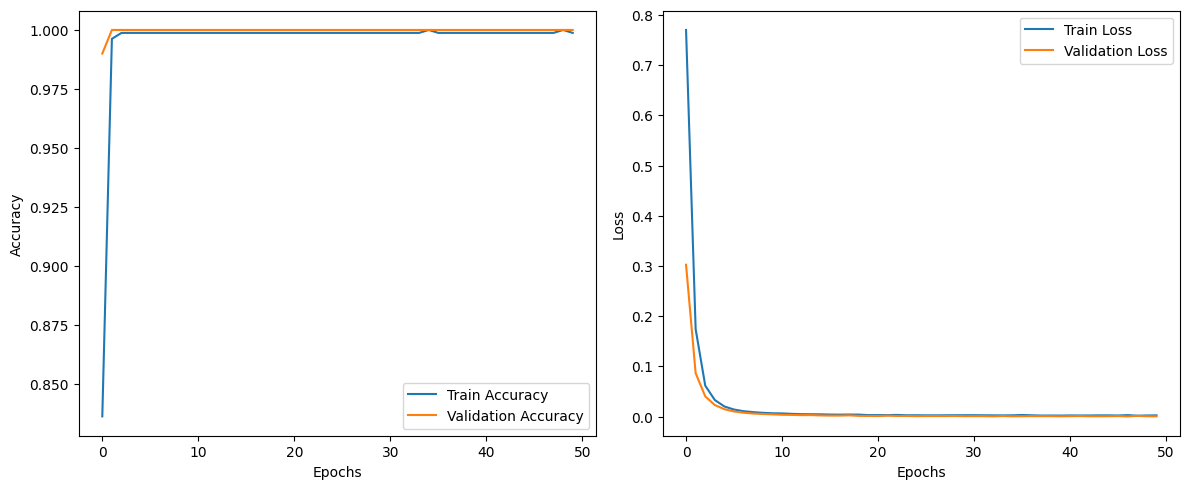

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import Callback
class PrintMetricsEvery10Epochs(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            print(f"\nEpoch {epoch + 1}")
            print(f"Train Loss: {logs['loss']:.4f} | Train Accuracy: {logs['accuracy']:.4f}")
            print(f"Val Loss: {logs['val_loss']:.4f} | Val Accuracy: {logs['val_accuracy']:.4f}")


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=0,
    callbacks=[PrintMetricsEvery10Epochs()]
)


Epoch 10
Train Loss: 0.0021 | Train Accuracy: 0.9987
Val Loss: 0.0008 | Val Accuracy: 1.0000

Epoch 20
Train Loss: 0.0018 | Train Accuracy: 1.0000
Val Loss: 0.0008 | Val Accuracy: 1.0000

Epoch 30
Train Loss: 0.0024 | Train Accuracy: 0.9987
Val Loss: 0.0008 | Val Accuracy: 1.0000

Epoch 40
Train Loss: 0.0015 | Train Accuracy: 1.0000
Val Loss: 0.0011 | Val Accuracy: 1.0000

Epoch 50
Train Loss: 0.0018 | Train Accuracy: 0.9987
Val Loss: 0.0008 | Val Accuracy: 1.0000
